## Define triangle sensor coords per place

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import pickle

## Load the merged CSV data

In [2]:
# Load SST (Sea Surface Temperature) and DHW (Degree Heating Week) data
df_sst = pd.read_csv('dataset/sst.csv', skiprows=[1])
df_dhw = pd.read_csv('dataset/dhw.csv', skiprows=[1])

In [3]:
# Check the data
print("SST Data Shape:", df_sst.shape)
print("DHW Data Shape:", df_dhw.shape)
df_sst.head()

SST Data Shape: (20094, 4)
DHW Data Shape: (20094, 4)


,time,latitude,longitude,analysed_sst
0,2015-03-02T12:00:00Z,6.125,80.075,29.13
1,2015-03-03T12:00:00Z,6.125,80.075,29.16
2,2015-03-04T12:00:00Z,6.125,80.075,29.55
3,2015-03-05T12:00:00Z,6.125,80.075,29.60
4,2015-03-06T12:00:00Z,6.125,80.075,29.58


## Merge the datasets

In [4]:
# Merge SST and DHW data on time and location
df = pd.merge(df_sst, df_dhw, on=['time', 'latitude', 'longitude'])
df['time'] = pd.to_datetime(df['time'])
print(f"Merged data shape: {df.shape}")
df.head()

Merged data shape: (20064, 5)


,time,latitude,longitude,analysed_sst,degree_heating_week
0,2015-03-02 12:00:00+00:00,6.125,80.075,29.13,0.0
1,2015-03-03 12:00:00+00:00,6.125,80.075,29.16,0.0
2,2015-03-04 12:00:00+00:00,6.125,80.075,29.55,0.0
3,2015-03-05 12:00:00+00:00,6.125,80.075,29.60,0.0
4,2015-03-06 12:00:00+00:00,6.125,80.075,29.58,0.0


## Define triangle sensor coords per place

In [5]:
# Small triangle offsets (degrees) around each base location — same as original
TRIANGLE_OFFSETS = [
    ( 0.005,  0.000),   # North
    (-0.005,  0.005),   # East
    (-0.005, -0.005),   # West
]

# One (lat, lon) per place, read from the merged data
base_locations = (
    df_sst.groupby(["latitude", "longitude"])
    .size()
    .reset_index()[["latitude", "longitude"]]
    .sort_values(["latitude", "longitude"])
    .values.tolist()
)

# Build all 15 sensor coords (3 triangle vertices per place)
sensor_coords = []
for base_lat, base_lon in base_locations:
    for dlat, dlon in TRIANGLE_OFFSETS:
        sensor_coords.append((round(base_lat + dlat, 4),
                              round(base_lon + dlon, 4)))

print(f"Base locations : {len(base_locations)}")
print(f"Total sensors  : {len(sensor_coords)}  (3 triangle vertices per place)")
for i, (lat, lon) in enumerate(sensor_coords, 1):
    print(f"  Sensor {i:2d}: lat={lat}, lon={lon}")


Base locations : 5
Total sensors  : 15  (3 triangle vertices per place)
  Sensor  1: lat=6.13, lon=80.075
  Sensor  2: lat=6.12, lon=80.08
  Sensor  3: lat=6.12, lon=80.07
  Sensor  4: lat=6.18, lon=81.475
  Sensor  5: lat=6.17, lon=81.48
  Sensor  6: lat=6.17, lon=81.47
  Sensor  7: lat=7.93, lon=81.575
  Sensor  8: lat=7.92, lon=81.58
  Sensor  9: lat=7.92, lon=81.57
  Sensor 10: lat=8.38, lon=79.725
  Sensor 11: lat=8.37, lon=79.73
  Sensor 12: lat=8.37, lon=79.72
  Sensor 13: lat=8.73, lon=81.175
  Sensor 14: lat=8.72, lon=81.18
  Sensor 15: lat=8.72, lon=81.17


## Simulate triangle sensors per place

In [6]:
# Get the base location from the actual data
base_lat = df['latitude'].iloc[0]
base_lon = df['longitude'].iloc[0]

print(f"Base location: {base_lat}, {base_lon}")
print(f"Number of time points: {len(df)}")

Base location: 6.125, 80.075
Number of time points: 20064


In [7]:
# Create data for all sensors — identical noise logic to original,
# now looped over every (base_location, triangle_vertex) pair.
all_sensors_data = []
sensor_num = 0

for base_lat, base_lon in base_locations:
    # Filter rows that belong to this place
    place_df = df[
        (df["latitude"] == base_lat) & (df["longitude"] == base_lon)
    ].copy()

    for dlat, dlon in TRIANGLE_OFFSETS:
        sensor_num += 1
        sensor_df = place_df.copy()
        # Move lat/lon to the triangle vertex
        sensor_df["latitude"]  = round(base_lat + dlat, 4)
        sensor_df["longitude"] = round(base_lon + dlon, 4)
        sensor_df["sensor_id"] = sensor_num

        # Add small random temperature variation — same seeds/range as original
        np.random.seed(42 + sensor_num)
        temp_offset = np.random.uniform(-0.2, 0.2, len(sensor_df))
        sensor_df["analysed_sst"] = sensor_df["analysed_sst"] + temp_offset

        # Add slight DHW variation
        dhw_offset = np.random.uniform(-0.05, 0.05, len(sensor_df))
        sensor_df["degree_heating_week"] = (
            sensor_df["degree_heating_week"] + dhw_offset
        ).clip(lower=0)

        all_sensors_data.append(sensor_df)
        print(f"Sensor {sensor_num:2d} data created: {len(sensor_df)} records  "
              f"(place={base_lat},{base_lon} -> vertex={sensor_df['latitude'].iloc[0]},"
              f"{sensor_df['longitude'].iloc[0]})")


Sensor  1 data created: 4012 records  (place=6.125,80.075 -> vertex=6.13,80.075)
Sensor  2 data created: 4012 records  (place=6.125,80.075 -> vertex=6.12,80.08)
Sensor  3 data created: 4012 records  (place=6.125,80.075 -> vertex=6.12,80.07)
Sensor  4 data created: 4013 records  (place=6.175,81.475 -> vertex=6.18,81.475)
Sensor  5 data created: 4013 records  (place=6.175,81.475 -> vertex=6.17,81.48)
Sensor  6 data created: 4013 records  (place=6.175,81.475 -> vertex=6.17,81.47)
Sensor  7 data created: 4013 records  (place=7.925,81.575 -> vertex=7.93,81.575)
Sensor  8 data created: 4013 records  (place=7.925,81.575 -> vertex=7.92,81.58)
Sensor  9 data created: 4013 records  (place=7.925,81.575 -> vertex=7.92,81.57)
Sensor 10 data created: 4013 records  (place=8.375,79.725 -> vertex=8.38,79.725)
Sensor 11 data created: 4013 records  (place=8.375,79.725 -> vertex=8.37,79.73)
Sensor 12 data created: 4013 records  (place=8.375,79.725 -> vertex=8.37,79.72)
Sensor 13 data created: 4013 records

In [8]:
# Combine all sensor data
df_triangle = pd.concat(all_sensors_data, ignore_index=True)
print(f"\nTotal combined data shape: {df_triangle.shape}")
print(f"Total records: {len(df_triangle)}")
df_triangle.head()


Total combined data shape: (60192, 6)
Total records: 60192


,time,latitude,longitude,analysed_sst,degree_heating_week,sensor_id
0,2015-03-02 12:00:00+00:00,6.13,80.075,28.976022,0.049361,1
1,2015-03-03 12:00:00+00:00,6.13,80.075,29.203627,0.000000,1
2,2015-03-04 12:00:00+00:00,6.13,80.075,29.403356,0.003853,1
3,2015-03-05 12:00:00+00:00,6.13,80.075,29.496236,0.026121,1
4,2015-03-06 12:00:00+00:00,6.13,80.075,29.510856,0.000000,1


## Convert time to days since start

In [9]:
# Convert time to numerical format (days since start)
df_triangle['days'] = (df_triangle['time'] - df_triangle['time'].min()).dt.days
df_triangle.head()

,time,latitude,longitude,analysed_sst,degree_heating_week,sensor_id,days
0,2015-03-02 12:00:00+00:00,6.13,80.075,28.976022,0.049361,1,1
1,2015-03-03 12:00:00+00:00,6.13,80.075,29.203627,0.000000,1,2
2,2015-03-04 12:00:00+00:00,6.13,80.075,29.403356,0.003853,1,3
3,2015-03-05 12:00:00+00:00,6.13,80.075,29.496236,0.026121,1,4
4,2015-03-06 12:00:00+00:00,6.13,80.075,29.510856,0.000000,1,5


## Visualize the sensor triangle

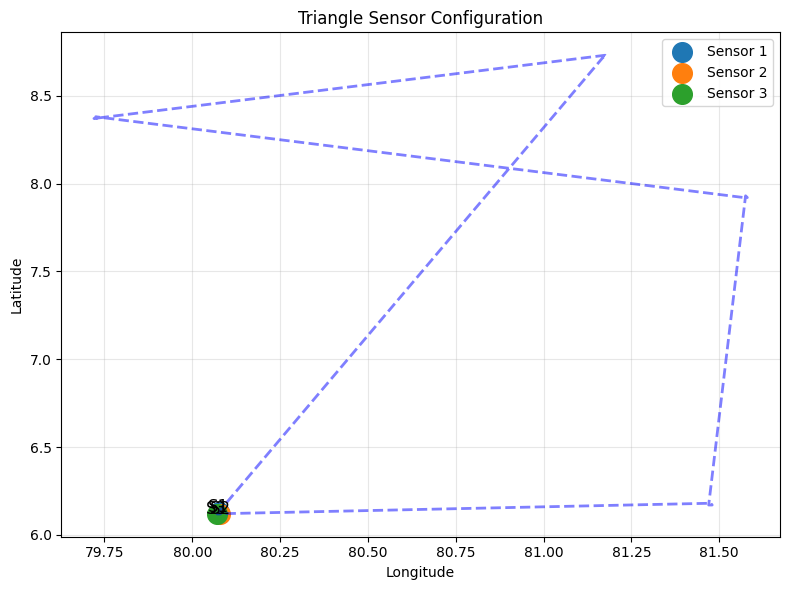

In [10]:
# Plot the triangle sensor locations
plt.figure(figsize=(8, 6))
for sensor_id in [1, 2, 3]:
    sensor_data = df_triangle[df_triangle['sensor_id'] == sensor_id]
    lat = sensor_data['latitude'].iloc[0]
    lon = sensor_data['longitude'].iloc[0]
    plt.scatter(lon, lat, s=200, label=f'Sensor {sensor_id}', marker='o')
    plt.text(lon, lat + 0.001, f'S{sensor_id}', ha='center', fontsize=12)

# Draw the triangle
triangle_lons = [coord[1] for coord in sensor_coords] + [sensor_coords[0][1]]
triangle_lats = [coord[0] for coord in sensor_coords] + [sensor_coords[0][0]]
plt.plot(triangle_lons, triangle_lats, 'b--', linewidth=2, alpha=0.5)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Triangle Sensor Configuration')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Normalize the data (0-1 range for Neural Network)

In [11]:
# Create scalers for each input dimension
scaler_lat = MinMaxScaler()
scaler_lon = MinMaxScaler()
scaler_time = MinMaxScaler()
scaler_temp = MinMaxScaler()
scaler_dhw = MinMaxScaler()

print("Scalers created successfully")

Scalers created successfully


In [12]:
# Fit and transform the data
df_triangle['lat_norm'] = scaler_lat.fit_transform(df_triangle[['latitude']])
df_triangle['lon_norm'] = scaler_lon.fit_transform(df_triangle[['longitude']])
df_triangle['time_norm'] = scaler_time.fit_transform(df_triangle[['days']])
df_triangle['temp_norm'] = scaler_temp.fit_transform(df_triangle[['analysed_sst']])
df_triangle['dhw_norm'] = scaler_dhw.fit_transform(df_triangle[['degree_heating_week']])

print("Data normalized successfully")
df_triangle.head()

Data normalized successfully


,time,latitude,longitude,analysed_sst,degree_heating_week,sensor_id,days,lat_norm,lon_norm,time_norm,temp_norm,dhw_norm
0,2015-03-02 12:00:00+00:00,6.13,80.075,28.976022,0.049361,1,1,0.003831,0.19086,0.000249,0.503454,0.004883
1,2015-03-03 12:00:00+00:00,6.13,80.075,29.203627,0.000000,1,2,0.003831,0.19086,0.000499,0.534052,0.000000
2,2015-03-04 12:00:00+00:00,6.13,80.075,29.403356,0.003853,1,3,0.003831,0.19086,0.000748,0.560904,0.000381
3,2015-03-05 12:00:00+00:00,6.13,80.075,29.496236,0.026121,1,4,0.003831,0.19086,0.000997,0.573390,0.002584
4,2015-03-06 12:00:00+00:00,6.13,80.075,29.510856,0.000000,1,5,0.003831,0.19086,0.001246,0.575356,0.000000


## Check normalization ranges

In [13]:
# Verify normalization
print("Normalized value ranges:")
print(f"  Latitude:    {df_triangle['lat_norm'].min():.4f} - {df_triangle['lat_norm'].max():.4f}")
print(f"  Longitude:   {df_triangle['lon_norm'].min():.4f} - {df_triangle['lon_norm'].max():.4f}")
print(f"  Time:        {df_triangle['time_norm'].min():.4f} - {df_triangle['time_norm'].max():.4f}")
print(f"  Temperature: {df_triangle['temp_norm'].min():.4f} - {df_triangle['temp_norm'].max():.4f}")
print(f"  DHW:         {df_triangle['dhw_norm'].min():.4f} - {df_triangle['dhw_norm'].max():.4f}")

Normalized value ranges:
  Latitude:    0.0000 - 1.0000
  Longitude:   0.0000 - 1.0000
  Time:        0.0000 - 1.0000
  Temperature: 0.0000 - 1.0000
  DHW:         0.0000 - 1.0000


## Prepare training data arrays

In [14]:
# Prepare input features (x, y, t) and output (T)
X_train = df_triangle[['lat_norm', 'lon_norm', 'time_norm']].values
y_train = df_triangle[['temp_norm']].values

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"\nSample input (normalized):")
print(X_train[:3])
print(f"\nSample output (normalized temperature):")
print(y_train[:3])

X_train shape: (60192, 3)
y_train shape: (60192, 1)

Sample input (normalized):
[[0.00383142 0.19086022 0.00024925]
 [0.00383142 0.19086022 0.0004985 ]
 [0.00383142 0.19086022 0.00074776]]

Sample output (normalized temperature):
[[0.50345384]
 [0.53405247]
 [0.56090364]]


## Save prepared data and scalers

In [15]:
# Save the processed data
df_triangle.to_csv('dataset/triangle_data.csv', index=False)
print("Saved triangle_data.csv")

Saved triangle_data.csv


In [16]:
# Save scalers for later use
scalers = {
    'scaler_lat': scaler_lat,
    'scaler_lon': scaler_lon,
    'scaler_time': scaler_time,
    'scaler_temp': scaler_temp,
    'scaler_dhw': scaler_dhw
}

with open('scalers.pkl', 'wb') as f:
    pickle.dump(scalers, f)
print("Saved scalers.pkl")

Saved scalers.pkl


In [17]:
# Save training arrays
np.save('X_train.npy', X_train)
np.save('y_train.npy', y_train)
print("Saved X_train.npy and y_train.npy")

Saved X_train.npy and y_train.npy


In [18]:
# Save sensor coordinates for visualization
sensor_info = {
    'sensor_coords': sensor_coords,
    'time_range': (df_triangle['time'].min(), df_triangle['time'].max()),
    'temp_range': (df_triangle['analysed_sst'].min(), df_triangle['analysed_sst'].max())
}

with open('sensor_info.pkl', 'wb') as f:
    pickle.dump(sensor_info, f)
print("Saved sensor_info.pkl")

Saved sensor_info.pkl


## Summary

In [19]:
print("="*60)
print("DATA PREPARATION COMPLETE")
print("="*60)
print(f"Total training samples : {len(X_train)}")
print(f"Base locations (places): {len(base_locations)}")
print(f"Sensors per place      : 3  (triangle)")
print(f"Total sensors          : {len(sensor_coords)}")
print(f"Records per sensor     : {len(df_triangle) // len(sensor_coords)}")
print(f"Date range : {df_triangle['time'].min()} to {df_triangle['time'].max()}")
print(f"Temp range : {df_triangle['analysed_sst'].min():.2f}C to {df_triangle['analysed_sst'].max():.2f}C")
print("\nFiles saved:")
print("  - dataset/triangle_data.csv")
print("  - X_train.npy")
print("  - y_train.npy")
print("  - scalers.pkl")
print("  - sensor_info.pkl")
print("\nReady for PINN model training!")
print("="*60)


DATA PREPARATION COMPLETE
Total training samples : 60192
Base locations (places): 5
Sensors per place      : 3  (triangle)
Total sensors          : 15
Records per sensor     : 4012
Date range : 2015-03-01 12:00:00+00:00 to 2026-02-23 12:00:00+00:00
Temp range : 25.23C to 32.67C

Files saved:
  - dataset/triangle_data.csv
  - X_train.npy
  - y_train.npy
  - scalers.pkl
  - sensor_info.pkl

Ready for PINN model training!
